In [2]:
import json
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import sys
from collections import defaultdict
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
from modules_segmentation import *


In [3]:
# load the results of a training

with open("/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics_train9/results.json", "r") as f:
    data = json.load(f)

#boxes in xyxy-format
print(data[0]["filename"])
box = data[0]["false_negatives"]["boxes"][1]
box

BRAIIM_0157.jpg


[1614.4910888671875, 1004.4244384765625, 1811.5557861328125, 1210.631591796875]

In [4]:
# function to compute if a box is covered by the mask (with a threshold)

def compute_mask_coverage(mask, rectangles, threshold=0.8):
    """
    mask: np.ndarray (grayscale, same size as original image)
    rectangles: list of rectangles [(x_min, y_min, x_max, y_max), ...]
    Returns: list of (rect_idx, coverage_ratio, is_covered)
    """
    results = []
    for i, (x1, y1, x2, y2) in enumerate(rectangles):
        #x2 = x1 + w
        #y2 = y1 + h
        # Ensure bounds within image
        x1, y1 = max(0, int(x1)), max(0, int(y1))
        x2, y2 = min(mask.shape[1], int(x2)), min(mask.shape[0], int(y2))
        if x2 <= x1 or y2 <= y1:
            results.append((i, 0.0, False))
            continue

        # Extract mask region
        region = mask[y1:y2, x1:x2]

        # Count masked pixels (assuming 0=masked, 255=background)
        masked_pixels = np.sum(region == 0)
        total_pixels = region.size
        ratio = masked_pixels / total_pixels

        is_covered = ratio >= threshold
        results.append((i, ratio, is_covered))
    return results

In [5]:
#set image folder and load the mask

image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/02_images_rotated"
label_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/02_labels_rotated"

processed_mask = cv2.imread(
    "/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/06_generated_mask_fat_plus.jpg", 
    cv2.IMREAD_GRAYSCALE
)

gridcorners = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/gridcorners.npy")
mask_h_line = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/mask_h_line.npy")

image_files = os.listdir(image_folder)

with open("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/logs/rotated_files_test_set.txt", "r") as f:
    files_rotated = set(line.strip() for line in f)

In [6]:
#function to adapt the mask to an inidivual image

def get_mask(image_file):
    image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/02_images_rotated"
    #Load image file
    print(f"Loading {image_file}")
    image = cv2.imread(os.path.join(image_folder, image_file))

    #find YST contour of image
    imageYST = find_contour(image)

    #save cropped image
    x, y, w, h = cv2.boundingRect(imageYST)
    

    #find corners if possible, if not skip the image
    imagecorners = find_corners(image, imageYST)
    if len(imagecorners) == 0:
        print(f"No YST found for {image_file}")
        return None

    #find transformation
    H, _ = cv2.findHomography(gridcorners, imagecorners, cv2.RANSAC)

    #first transformation: 
    mask = cv2.warpPerspective(processed_mask, H, (image.shape[1], image.shape[0]))
    
    #transform midline of mask as above
    h_line_pts = mask_h_line.reshape(-1,1,2)
    h_line_pts_warped = cv2.perspectiveTransform(h_line_pts, H)
    x1w, y1w, x2w, y2w = h_line_pts_warped.reshape(-1).astype(np.int32)
    mask_h = (x1w, y1w, x2w, y2w)

    #second transformation: correct vertical misalignment
    image_h = get_h_mid(create_binary_mask(image))
    dy = get_midpoint(image_h)- get_midpoint(mask_h)
    print (dy)
    if abs(dy) > 500:
        print(f"Skipped vertical alignment, wrong horizontal line with offset {dy}")
    else:
        H, W = mask.shape[:2]
        M = np.float32([[1, 0, 0], [0, 1, dy]])  # translation matrix
        mask= cv2.warpAffine(mask, M, (W, H), borderValue=255)  # white background
    return mask[y:y+h, x:x+w]

Loading BRAIIM_0170.jpg
using only simple binarization.
using only simple binarization.
113.0
Rotate mask


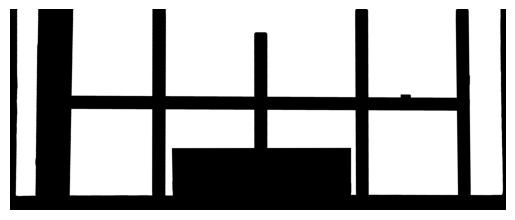

In [7]:
#get the mask for an image and rotate it back if original image was rotated
f = data[1]["filename"]
mask = get_mask(f)
if f in files_rotated:
    print("Rotate mask")
    mask = cv2.rotate(mask, cv2.ROTATE_180)
rgb_image = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()

In [17]:
#compute which rectangles are overlapping with the mask
r = data[1]["false_negatives"]["boxes"]
overlaps = compute_mask_coverage(mask, r, threshold = 0.5)
overlaps

[(0, np.float64(0.8309535658232209), np.True_),
 (1, np.float64(0.06650488770861473), np.False_),
 (2, np.float64(0.5779560439560439), np.True_),
 (3, np.float64(1.0), np.True_),
 (4, np.float64(1.0), np.True_),
 (5, np.float64(1.0), np.True_),
 (6, np.float64(0.0), np.False_),
 (7, np.float64(0.7418181818181818), np.True_),
 (8, np.float64(0.5117797695262484), np.True_),
 (9, np.float64(0.0), np.False_),
 (10, np.float64(1.0), np.True_),
 (11, np.float64(1.0), np.True_),
 (12, np.float64(0.22002571520411443), np.False_),
 (13, np.float64(0.0), np.False_),
 (14, np.float64(0.9725274725274725), np.True_),
 (15, np.float64(1.0), np.True_),
 (16, np.float64(0.8035714285714286), np.True_),
 (17, np.float64(1.0), np.True_),
 (18, np.float64(0.1717171717171717), np.False_)]

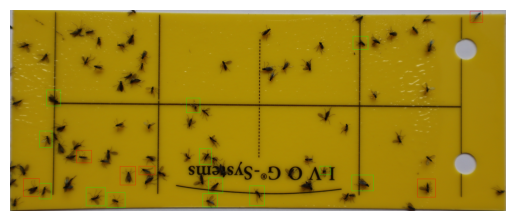

In [18]:
#plot rectangles on image
#green: on mask, red: not (remains false negative)
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/images"
img_copy = cv2.imread(os.path.join(image_folder, f))
for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=2)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=2)

img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

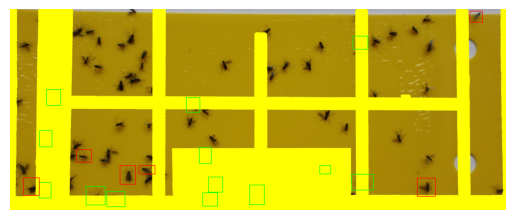

In [20]:
#same for masked image
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/03_images_masked"
img_copy = cv2.imread(os.path.join(image_folder, f))
if f in files_rotated:
    img_copy = cv2.rotate(img_copy, cv2.ROTATE_180)

for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=5)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=5)

img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
cv2.imwrite("false_negatives_on_mask.jpg",img_copy)

plt.show()

In [24]:
#per class results

# Initialize per-class counters
stats = defaultdict(lambda: {"true": 0, "false": 0, "unchecked": 0})

for d in data:
    f = d["filename"]

    # Determine class from filename prefix
    if f.startswith("BRAIIM"):
        cls = "BRAIIM"
    elif f.startswith("LIRIBO"):
        cls = "LIRIBO"
    elif f.startswith("TRIAVA"):
        cls = "TRIAVA"
    else:
        cls = "UNKNOWN"

    r = d["false_negatives"]["boxes"]
    mask = get_mask(f)

    if mask is None:
        stats[cls]["unchecked"] += len(r)
        continue

    if f in files_rotated:
        print(f"Rotate mask for {f}")
        mask = cv2.rotate(mask, cv2.ROTATE_180)

    overlaps = compute_mask_coverage(mask, r)

    stats[cls]["true"] += sum(1 for _, _, val in overlaps if val)
    stats[cls]["false"] += sum(1 for _, _, val in overlaps if not val)

# Print per-class results
for cls, counts in stats.items():
    print(f"\nClass: {cls}")
    print(f"  True:      {counts['true']}")
    print(f"  False:     {counts['false']}")
    print(f"  Unchecked: {counts['unchecked']}")

# Optional: total summary
total_true = sum(c["true"] for c in stats.values())
total_false = sum(c["false"] for c in stats.values())
total_unchecked = sum(c["unchecked"] for c in stats.values())

print("\nOverall totals:")
print(f"  True:      {total_true}")
print(f"  False:     {total_false}")
print(f"  Unchecked: {total_unchecked}")


Loading BRAIIM_0157.jpg
using only simple binarization.
No YST found for BRAIIM_0157.jpg
Loading BRAIIM_0170.jpg
using only simple binarization.
using only simple binarization.
113.0
Rotate mask for BRAIIM_0170.jpg
Loading BRAIIM_0184.jpg
using only simple binarization.
using only simple binarization.
94.0
Rotate mask for BRAIIM_0184.jpg
Loading BRAIIM_0195.jpg
using only simple binarization.
No YST found for BRAIIM_0195.jpg
Loading BRAIIM_0204.jpg
using only simple binarization.
using only simple binarization.
101.0
Rotate mask for BRAIIM_0204.jpg
Loading BRAIIM_0207.jpg
using only simple binarization.
using only simple binarization.
84.0
Rotate mask for BRAIIM_0207.jpg
Loading BRAIIM_0223.jpg
using only simple binarization.
using only simple binarization.
30.0
Rotate mask for BRAIIM_0223.jpg
Loading BRAIIM_0286.jpg
using only simple binarization.
using only simple binarization.
33.5
Rotate mask for BRAIIM_0286.jpg
Loading BRAIIM_0288.jpg
using only simple binarization.
using only sim

In [25]:
stats

defaultdict(<function __main__.<lambda>()>,
            {'BRAIIM': {'true': 197, 'false': 244, 'unchecked': 93},
             'LIRIBO': {'true': 106, 'false': 105, 'unchecked': 19},
             'TRIAVA': {'true': 711, 'false': 1070, 'unchecked': 69}})

In [26]:
#load metrics

with open("/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics_train9/metrics.json", "r") as f:
    metrics = json.load(f)
metrics

import pandas as pd
# Combine summary and per-class metrics
rows = {'summary': metrics['summary']}
rows.update(metrics['per_class'])

# Create DataFrame
df = pd.DataFrame(rows).T

# Compute F1 for each row
df['f1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

df

,TP,FP,FN,precision,recall,f1
summary,2846.0,573.0,2614.0,0.832407,0.521245,0.641063
0,1045.0,236.0,534.0,0.815769,0.661811,0.730769
1,1029.0,297.0,230.0,0.776018,0.817315,0.796132
3,772.0,40.0,1850.0,0.950739,0.294432,0.449621


In [27]:
def add_row_fn(df, row_name, mask_value):
    base = df.loc[row_name].copy()

    # Recalculate derived metrics
    tp, fp, fn = base['TP'], base['FP'], base['FN']-mask_value
    precision = tp / (tp + fp) if tp + fp > 0 else 0

    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(recall)

    # Create new row
    new_row = base.copy()
    print(new_row)
    new_row["FN"] = fn
    new_row['precision'] = precision
    new_row['recall'] = recall
    new_row['f1'] = f1
    return new_row

#subtract the false negatives correlated to masking
df.loc["summary_fn_masked"] = add_row_fn(df, "summary", 197 + 106 + 711)
df.loc["0_fn_masked"] = add_row_fn(df, "0", 197)
df.loc["1_fn_masked"] = add_row_fn(df, "1", 106)
df.loc["3_fn_masked"] = add_row_fn(df, "3", 711)
df

0.6401259559154296
TP           2846.000000
FP            573.000000
FN           2614.000000
precision       0.832407
recall          0.521245
f1              0.641063
Name: summary, dtype: float64
0.756150506512301
TP           1045.000000
FP            236.000000
FN            534.000000
precision       0.815769
recall          0.661811
f1              0.730769
Name: 0, dtype: float64
0.8924544666088465
TP           1029.000000
FP            297.000000
FN            230.000000
precision       0.776018
recall          0.817315
f1              0.796132
Name: 1, dtype: float64
0.40397697540554683
TP            772.000000
FP             40.000000
FN           1850.000000
precision       0.950739
recall          0.294432
f1              0.449621
Name: 3, dtype: float64


,TP,FP,FN,precision,recall,f1
summary,2846.0,573.0,2614.0,0.832407,0.521245,0.641063
0,1045.0,236.0,534.0,0.815769,0.661811,0.730769
1,1029.0,297.0,230.0,0.776018,0.817315,0.796132
3,772.0,40.0,1850.0,0.950739,0.294432,0.449621
summary_fn_masked,2846.0,573.0,1600.0,0.832407,0.640126,0.723713
0_fn_masked,1045.0,236.0,337.0,0.815769,0.756151,0.784829
1_fn_masked,1029.0,297.0,124.0,0.776018,0.892454,0.830173
3_fn_masked,772.0,40.0,1139.0,0.950739,0.403977,0.567022


Loading BRAIIM_0319.jpg
using only simple binarization.


using only simple binarization.
31.5
Rotate mask


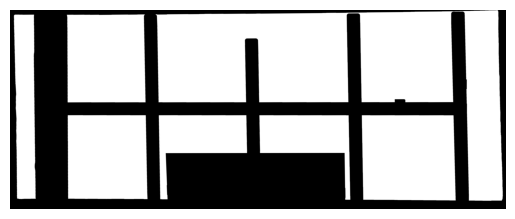

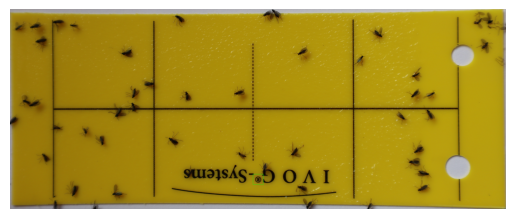

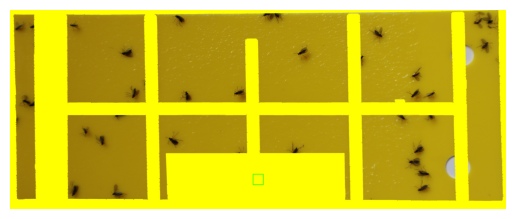

[(0, np.float64(1.0), np.True_)]


In [23]:
#get the mask for an image and rotate it back if original image was rotated
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/02_images_rotated"
i = 10
f = data[i]["filename"]
mask = get_mask(f)
if f in files_rotated:
    print("Rotate mask")
    mask = cv2.rotate(mask, cv2.ROTATE_180)
rgb_image = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()
#compute which rectangles are overlapping with the mask
r = data[i]["false_positives"]["boxes"]
overlaps = compute_mask_coverage(mask, r, threshold = 1.0)
#plot rectangles on image
#green: on mask, red: not (remains false negative)
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/images"
img_copy = cv2.imread(os.path.join(image_folder, f))
for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=2)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=2)

img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()
#same for masked image
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/03_images_masked"
img_copy = cv2.imread(os.path.join(image_folder, f))
if f in files_rotated:
    img_copy = cv2.rotate(img_copy, cv2.ROTATE_180)

for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=5)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=5)

cv2.imwrite("false_positives_on_mask.jpg",img_copy)
img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()
print(overlaps)

In [116]:
#per class results
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/02_images_rotated"

# Initialize per-class counters
stats = defaultdict(lambda: {"true": 0, "false": 0, "unchecked": 0})

for d in data:
    f = d["filename"]

    # Determine class from filename prefix
    if f.startswith("BRAIIM"):
        cls = "BRAIIM"
    elif f.startswith("LIRIBO"):
        cls = "LIRIBO"
    elif f.startswith("TRIAVA"):
        cls = "TRIAVA"
    else:
        cls = "UNKNOWN"

    r = d["false_positives"]["boxes"]
    mask = get_mask(f)

    if mask is None:
        stats[cls]["unchecked"] += len(r)
        continue

    if f in files_rotated:
        print(f"Rotate mask for {f}")
        mask = cv2.rotate(mask, cv2.ROTATE_180)

    overlaps = compute_mask_coverage(mask, r, threshold = 1.0)

    stats[cls]["true"] += sum(1 for _, _, val in overlaps if val)
    stats[cls]["false"] += sum(1 for _, _, val in overlaps if not val)

# Print per-class results
for cls, counts in stats.items():
    print(f"\nClass: {cls}")
    print(f"  True:      {counts['true']}")
    print(f"  False:     {counts['false']}")
    print(f"  Unchecked: {counts['unchecked']}")

# Optional: total summary
total_true = sum(c["true"] for c in stats.values())
total_false = sum(c["false"] for c in stats.values())
total_unchecked = sum(c["unchecked"] for c in stats.values())

print("\nOverall totals:")
print(f"  True:      {total_true}")
print(f"  False:     {total_false}")
print(f"  Unchecked: {total_unchecked}")

Loading BRAIIM_0157.jpg
using only simple binarization.
No YST found for BRAIIM_0157.jpg
Loading BRAIIM_0170.jpg
using only simple binarization.
using only simple binarization.
113.0
Rotate mask for BRAIIM_0170.jpg
Loading BRAIIM_0184.jpg
using only simple binarization.
using only simple binarization.
94.0
Rotate mask for BRAIIM_0184.jpg
Loading BRAIIM_0195.jpg
using only simple binarization.
No YST found for BRAIIM_0195.jpg
Loading BRAIIM_0204.jpg
using only simple binarization.
using only simple binarization.
101.0
Rotate mask for BRAIIM_0204.jpg
Loading BRAIIM_0207.jpg
using only simple binarization.
using only simple binarization.
84.0
Rotate mask for BRAIIM_0207.jpg
Loading BRAIIM_0223.jpg
using only simple binarization.
using only simple binarization.
30.0
Rotate mask for BRAIIM_0223.jpg
Loading BRAIIM_0286.jpg
using only simple binarization.
using only simple binarization.
33.5
Rotate mask for BRAIIM_0286.jpg
Loading BRAIIM_0288.jpg
using only simple binarization.
using only sim

In [128]:
stats

defaultdict(<function __main__.<lambda>()>,
            {'BRAIIM': {'true': 40, 'false': 183, 'unchecked': 30},
             'LIRIBO': {'true': 110, 'false': 102, 'unchecked': 25},
             'TRIAVA': {'true': 42, 'false': 38, 'unchecked': 3}})

In [28]:
def add_row_fp(df, row_name, mask_value):
    base = df.loc[row_name].copy()

    # Recalculate derived metrics
    tp, fp, fn = base['TP'], base['FP']-mask_value, base['FN']
    precision = tp / (tp + fp) if tp + fp > 0 else 0

    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(recall)

    # Create new row
    new_row = base.copy()
    print(new_row)
    new_row["FP"] = fp
    new_row['precision'] = precision
    new_row['recall'] = recall
    new_row['f1'] = f1
    return new_row

#subtract the false negatives correlated to masking
df.loc["summary_fp_masked"] = add_row_fp(df, "summary_fn_masked", 40+110+42)
df.loc["0_fp_masked"] = add_row_fp(df, "0_fn_masked", 40)
df.loc["1_fp_masked"] = add_row_fp(df, "1_fn_masked", 110)
df.loc["3_fp_masked"] = add_row_fp(df, "3_fn_masked", 42)
df

0.6401259559154296
TP           2846.000000
FP            573.000000
FN           1600.000000
precision       0.832407
recall          0.640126
f1              0.723713
Name: summary_fn_masked, dtype: float64
0.756150506512301
TP           1045.000000
FP            236.000000
FN            337.000000
precision       0.815769
recall          0.756151
f1              0.784829
Name: 0_fn_masked, dtype: float64
0.8924544666088465
TP           1029.000000
FP            297.000000
FN            124.000000
precision       0.776018
recall          0.892454
f1              0.830173
Name: 1_fn_masked, dtype: float64
0.40397697540554683
TP            772.000000
FP             40.000000
FN           1139.000000
precision       0.950739
recall          0.403977
f1              0.567022
Name: 3_fn_masked, dtype: float64


,TP,FP,FN,precision,recall,f1
summary,2846.0,573.0,2614.0,0.832407,0.521245,0.641063
0,1045.0,236.0,534.0,0.815769,0.661811,0.730769
1,1029.0,297.0,230.0,0.776018,0.817315,0.796132
3,772.0,40.0,1850.0,0.950739,0.294432,0.449621
summary_fn_masked,2846.0,573.0,1600.0,0.832407,0.640126,0.723713
0_fn_masked,1045.0,236.0,337.0,0.815769,0.756151,0.784829
1_fn_masked,1029.0,297.0,124.0,0.776018,0.892454,0.830173
3_fn_masked,772.0,40.0,1139.0,0.950739,0.403977,0.567022
summary_fp_masked,2846.0,381.0,1600.0,0.881934,0.640126,0.741822
0_fp_masked,1045.0,196.0,337.0,0.842063,0.756151,0.796798


In [156]:
def mean_hsv_otsu(box, img):
    x1, y1, x2, y2 = map(int, box)
    roi = img[y1:y2, x1:x2]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    v_channel = hsv[:, :, 2]

    # Apply Otsu's threshold on V
    _, mask = cv2.threshold(v_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Convert mask to boolean for indexing
    mask_bool = mask == 255

    s_pixels = hsv[:, :, 1][mask_bool]
    v_pixels = hsv[:, :, 2][mask_bool]

    if s_pixels.size == 0 or v_pixels.size == 0:
        return (np.nan, np.nan)

    mean_s = float(np.mean(s_pixels))
    mean_v = float(np.mean(v_pixels))

    return (mean_s, mean_v)


def mean_hsv_box(box, img):
    x1, y1, x2, y2 = map(int, box)
    roi = img[y1:y2, x1:x2]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    return hsv[:, :, 1].mean(), hsv[:, :, 2].mean()  # (S, V)

In [153]:
tp_s_means = []
tp_v_means = []
fn_s_means = []
fn_v_means = []

for i in range(len(data)):
    f = data[i]["filename"]
    if not f.startswith("TRIAVA"):
        continue

    fn = data[i]["false_negatives"]["boxes"]
    tp = data[i]["true_positives"]["boxes"]

    mask = get_mask(f)
    if mask is None:
        print(f"No mask detectable for {f}.")
        continue

    if f in files_rotated:
        print(f"Rotate mask for {f}")
        mask = cv2.rotate(mask, cv2.ROTATE_180)

    overlaps = compute_mask_coverage(mask, fn, threshold=0.2)
    filtered_fn = [box for i, box in enumerate(fn) if not overlaps[i][2]]

    img = cv2.imread(os.path.join(
        "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/images", f
    ))

    fn_sv = [mean_hsv_box(box, img) for box in filtered_fn]
    tp_sv = [mean_hsv_box(box, img) for box in tp]

    if fn_sv:  # only if not empty
        fn_s, fn_v = zip(*fn_sv)
        fn_s_means.extend(fn_s)
        fn_v_means.extend(fn_v)

    if tp_sv:
        tp_s, tp_v = zip(*tp_sv)
        tp_s_means.extend(tp_s)
        tp_v_means.extend(tp_v)


        



'''

for box in fn:
    x1,y1,x2,y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=2)
for box in tp:
    x1,y1,x2,y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=2)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()
                
'''

Loading TRIAVA_0007.jpg
using only simple binarization.
using only simple binarization.
2.5
Rotate mask for TRIAVA_0007.jpg
Loading TRIAVA_0019.jpg
using only simple binarization.
using only simple binarization.
65.0
Loading TRIAVA_0028.jpg
using only simple binarization.
using only simple binarization.
62.5
Rotate mask for TRIAVA_0028.jpg
Loading TRIAVA_0140.jpg
using only simple binarization.
using only simple binarization.
54.5
Rotate mask for TRIAVA_0140.jpg
Loading TRIAVA_0180.jpg
using only simple binarization.
using only simple binarization.
22.0
Rotate mask for TRIAVA_0180.jpg
Loading TRIAVA_0184.jpg
using only simple binarization.
using only simple binarization.
31.0
Rotate mask for TRIAVA_0184.jpg
Loading TRIAVA_0185.jpg
using only simple binarization.
using only simple binarization.
16.5
Rotate mask for TRIAVA_0185.jpg
Loading TRIAVA_0187.jpg
using only simple binarization.
using only simple binarization.
45.0
Rotate mask for TRIAVA_0187.jpg
Loading TRIAVA_0188.jpg
using onl

'\n\nfor box in fn:\n    x1,y1,x2,y2 = map(int, box)\n    cv2.rectangle(img, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=2)\nfor box in tp:\n    x1,y1,x2,y2 = map(int, box)\n    cv2.rectangle(img, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=2)\nimg_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\nplt.imshow(img_rgb)\nplt.axis("off")\nplt.show()\n\n'

In [154]:
print("Mean Saturation (FN):", np.mean(fn_s_means))
print("Mean Value (FN):", np.mean(fn_v_means))
print("Mean Saturation (TP):", np.mean(tp_s_means))
print("Mean Value (TP):", np.mean(tp_v_means))


Mean Saturation (FN): 200.17060234878147
Mean Value (FN): 155.40734896270502
Mean Saturation (TP): 175.05194383104947
Mean Value (TP): 158.04063827992272


/mnt/lustre-grete/tmp/u15287/ipykernel_2505004/3361097888.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fn_v_means, tp_v_means], labels=["FN", "TP"])


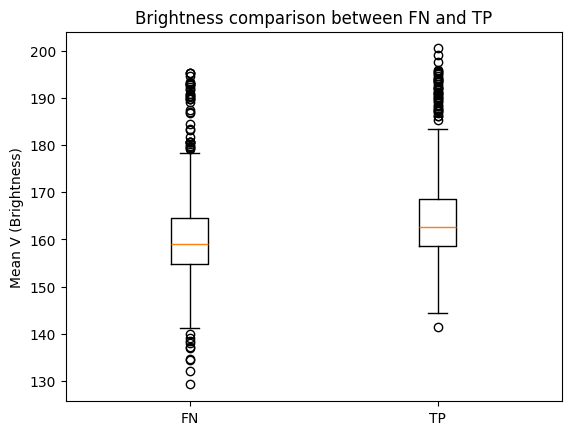

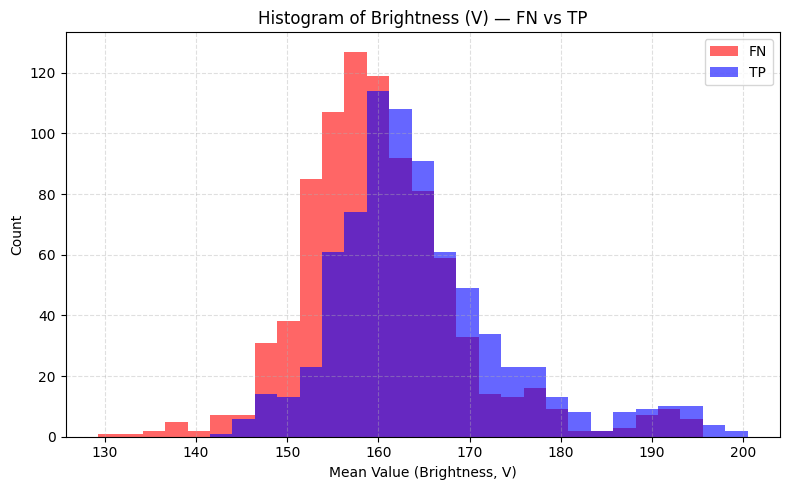

In [158]:
import matplotlib.pyplot as plt

plt.boxplot([fn_v_means, tp_v_means], labels=["FN", "TP"])
plt.ylabel("Mean V (Brightness)")
plt.title("Brightness comparison between FN and TP")
plt.show() 

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

bins = np.linspace(
    min(np.nanmin(fn_v_means), np.nanmin(tp_v_means)),
    max(np.nanmax(fn_v_means), np.nanmax(tp_v_means)),
    30
)

plt.hist(fn_v_means, bins=bins, alpha=0.6, label="FN", color="red")
plt.hist(tp_v_means, bins=bins, alpha=0.6, label="TP", color="blue")

plt.xlabel("Mean Value (Brightness, V)")
plt.ylabel("Count")
plt.title("Histogram of Brightness (V) — FN vs TP")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [157]:
tp_s_means = []
tp_v_means = []
fn_s_means = []
fn_v_means = []

for i in range(len(data)):
    f = data[i]["filename"]
    if not f.startswith("TRIAVA"):
        continue

    fn = data[i]["false_negatives"]["boxes"]
    tp = data[i]["true_positives"]["boxes"]

    mask = get_mask(f)
    if mask is None:
        print(f"No mask detectable for {f}.")
        continue

    if f in files_rotated:
        print(f"Rotate mask for {f}")
        mask = cv2.rotate(mask, cv2.ROTATE_180)

    overlaps = compute_mask_coverage(mask, fn, threshold=0.2)
    filtered_fn = [box for i, box in enumerate(fn) if not overlaps[i][2]]

    img = cv2.imread(os.path.join(
        "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/images", f
    ))

    fn_sv = [mean_hsv_otsu(box, img) for box in filtered_fn]
    tp_sv = [mean_hsv_otsu(box, img) for box in tp]

    if fn_sv:  # only if not empty
        fn_s, fn_v = zip(*fn_sv)
        fn_s_means.extend(fn_s)
        fn_v_means.extend(fn_v)

    if tp_sv:
        tp_s, tp_v = zip(*tp_sv)
        tp_s_means.extend(tp_s)
        tp_v_means.extend(tp_v)



Loading TRIAVA_0007.jpg
using only simple binarization.
using only simple binarization.
2.5
Rotate mask for TRIAVA_0007.jpg
Loading TRIAVA_0019.jpg
using only simple binarization.
using only simple binarization.
65.0
Loading TRIAVA_0028.jpg
using only simple binarization.
using only simple binarization.
62.5
Rotate mask for TRIAVA_0028.jpg
Loading TRIAVA_0140.jpg
using only simple binarization.
using only simple binarization.
54.5
Rotate mask for TRIAVA_0140.jpg
Loading TRIAVA_0180.jpg
using only simple binarization.
using only simple binarization.
22.0
Rotate mask for TRIAVA_0180.jpg
Loading TRIAVA_0184.jpg
using only simple binarization.
using only simple binarization.
31.0
Rotate mask for TRIAVA_0184.jpg
Loading TRIAVA_0185.jpg
using only simple binarization.
using only simple binarization.
16.5
Rotate mask for TRIAVA_0185.jpg
Loading TRIAVA_0187.jpg
using only simple binarization.
using only simple binarization.
45.0
Rotate mask for TRIAVA_0187.jpg
Loading TRIAVA_0188.jpg
using onl

In [159]:
print("Mean Saturation (FN):", np.mean(fn_s_means))
print("Mean Value (FN):", np.mean(fn_v_means))
print("Mean Saturation (TP):", np.mean(tp_s_means))
print("Mean Value (TP):", np.mean(tp_v_means))

Mean Saturation (FN): 203.09255896234328
Mean Value (FN): 160.38302054860162
Mean Saturation (TP): 169.32488307077892
Mean Value (TP): 164.67188689832398


/mnt/lustre-grete/tmp/u15287/ipykernel_2505004/3361097888.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fn_v_means, tp_v_means], labels=["FN", "TP"])


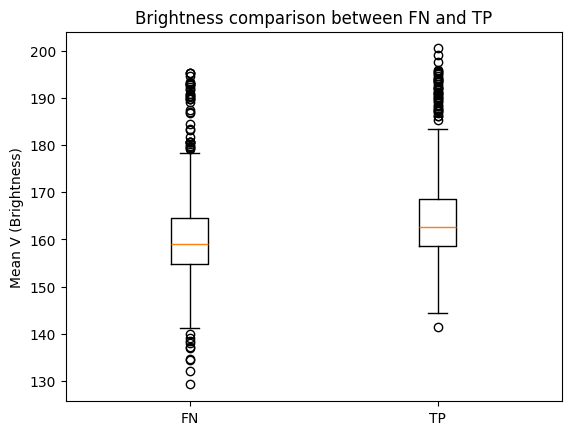

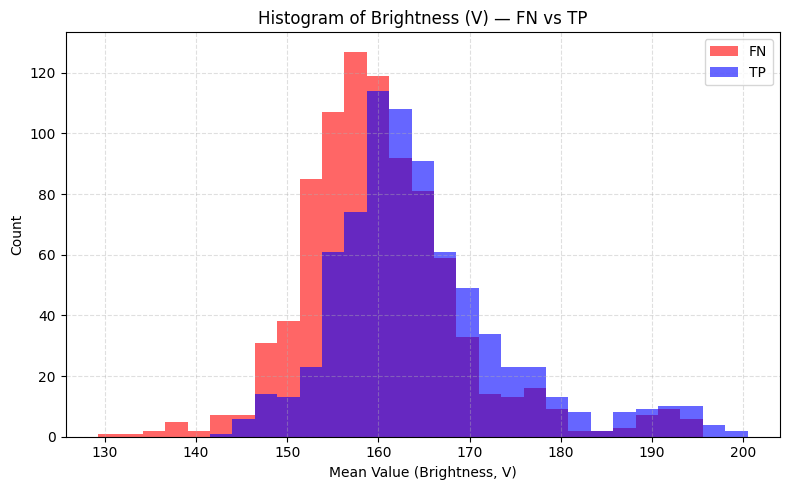

In [160]:
import matplotlib.pyplot as plt

plt.boxplot([fn_v_means, tp_v_means], labels=["FN", "TP"])
plt.ylabel("Mean V (Brightness)")
plt.title("Brightness comparison between FN and TP")
plt.show() 

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

bins = np.linspace(
    min(np.nanmin(fn_v_means), np.nanmin(tp_v_means)),
    max(np.nanmax(fn_v_means), np.nanmax(tp_v_means)),
    30
)

plt.hist(fn_v_means, bins=bins, alpha=0.6, label="FN", color="red")
plt.hist(tp_v_means, bins=bins, alpha=0.6, label="TP", color="blue")

plt.xlabel("Mean Value (Brightness, V)")
plt.ylabel("Count")
plt.title("Histogram of Brightness (V) — FN vs TP")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()